In [1]:
import os
import pyvista as pv
import matplotlib.pyplot as plt
from glob import glob
from natsort import natsorted
os.environ['PYVISTA_OFF_SCREEN'] = 'true'
pv.set_jupyter_backend('client')# pv.start_xvfb()                              
pv.global_theme.trame.server_proxy_enabled = True
pv.global_theme.trame.server_proxy_prefix = "/proxy/"

In [2]:
base_pth = "/gpfs/home/cw1722/sponge/JAX-LaB/results/co2"
# base_pth = "/gpfs/home/cw1722/sponge/JAX-LaB/results/gdl"
out_pth = os.path.join(base_pth, "output")
out_sim = glob(out_pth + "/*.vtk")
out_sim = natsorted(out_sim)
print(len(out_sim))

31


In [8]:
idx = 15
print(out_sim[idx])
sample = pv.read(out_sim[idx])
print(sample)

/gpfs/home/cw1722/sponge/JAX-LaB/results/co2/output/data_0015000.vtk
ImageData (0x153988e27460)
  N Cells:      19999960
  N Points:     20222775
  X Bounds:     0.000e+00, 3.100e+02
  Y Bounds:     0.000e+00, 2.540e+02
  Z Bounds:     0.000e+00, 2.540e+02
  Dimensions:   311, 255, 255
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     17


In [9]:
print(sample.array_names)        # list all 17 field names 
print(sample['rho_water'].shape)

['rho', 'ux', 'uy', 'uz', 'ux_CO2', 'uy_CO2', 'uz_CO2', 'ux_water', 'uy_water', 'uz_water', 'rho_water', 'rho_CO2', 'p_CO2', 'p_water', 'phi_w', 'theta_c', 'flag']
(19999960,)


In [10]:
def get_phase(sample, nwp_key, wp_key, target="nwp"):
    nx, ny, nz = sample.dimensions
    nwp = sample[nwp_key].reshape(nx-1, ny-1, nz-1, order='F')
    wp = sample[wp_key].reshape(nx-1, ny-1, nz-1, order='F')
    out = nwp > wp if target == "nwp" else nwp < wp
    return out

def get_rock(sample):
    nx, ny, nz = sample.dimensions
    out = sample['flag'].reshape(nx-1, ny-1, nz-1, order='F')
    return out

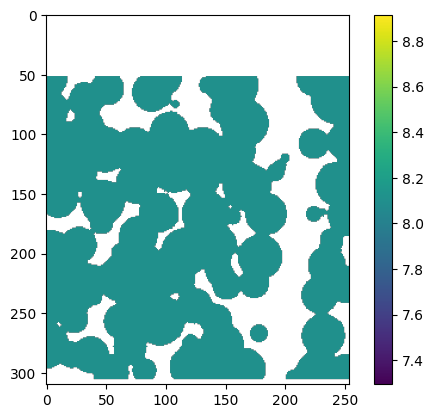

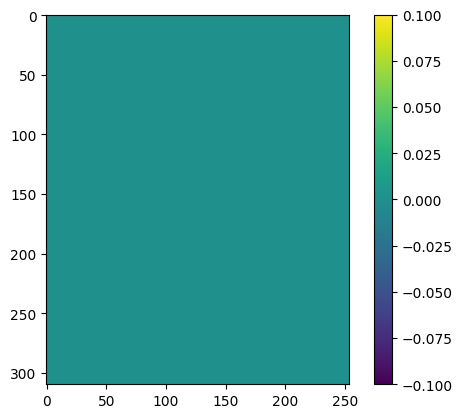

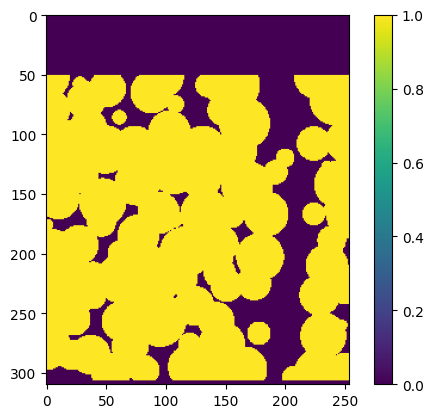

In [11]:
name = "rho_water"
nx, ny, nz = sample.dimensions
target = sample[name].reshape(nx-1, ny-1, nz-1, order='F')
phase =  get_phase(sample, "rho_CO2", "rho_water", target="nwp")
rock = get_rock(sample)

plt.imshow(target[:, :, 200])
plt.colorbar()
plt.show()
plt.imshow(phase[:, :, 200])
plt.colorbar()
plt.show()
plt.imshow(rock[:, :, 200])
plt.colorbar()

In [12]:
target

pyvista_ndarray([[[nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan],
                  ...,
                  [nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan]],

                 [[nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan],
                  ...,
                  [nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan]],

                 [[nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan, nan],
                  ...,
                  [nan, nan, nan, ..., nan, nan, nan],
                  [nan, nan, nan, ..., nan, nan